In [1]:
# Magic formulae so that changes in the .py files are loaded in here
%load_ext autoreload
%autoreload 2
###

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from tqdm.auto import tqdm
import copy

import pandas as pd
import xarray as xr

import torch.nn as nn
import torch.optim as optim
import random
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
import sklearn


/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import os

def reset_seeds(seed=1):
    # Ensure reproducibility
    # https://docs.pytorch.org/docs/stable/notes/randomness.html
    torch.manual_seed(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True
    random.seed(seed)
    np.random.seed(seed)
# torch.manual_seed(3)
reset_seeds(1)

In [3]:
ds = xr.open_dataset('data_input/Cyclostationary_LIM_ORAS5_XRO10_GlobColour_PP_RECCAP2_all_regions_valid_zero30_1998_2025.nc')
ds

<xarray.Dataset> Size: 942kB
Dimensions:                                (region: 21, month: 12,
                                            state_to: 11, state_from: 11,
                                            state: 11, time: 336, poly_coeff: 2)
Coordinates:
  * region                                 (region) int16 42B 1 2 3 ... 27 28 29
  * month                                  (month) int16 24B 1 2 3 ... 10 11 12
  * state_to                               (state_to) <U5 220B 'PP' ... 'SASD'
  * state_from                             (state_from) <U5 220B 'PP' ... 'SASD'
  * state                                  (state) <U5 220B 'PP' ... 'SASD'
  * time                                   (time) datetime64[ns] 3kB 1998-01-...
  * poly_coeff                             (poly_coeff) int64 16B 0 1
Data variables: (12/24)
    G                                      (region, month, state_to, state_from) float32 122kB ...
    C0                                     (region, month, state_to, state_from) float32 122kB ...
    C1                                     (region, month, state_to, state_from) float32 122kB ...
    Q                                      (region, month, state_to, state_from) float32 122kB ...
    n_samples                              (region, month) int16 504B ...
    fit_mean_x                             (region, month, state) float32 11kB ...
    ...                                     ...
    original_region_id                     (region) int16 42B ...
    n_total_cells_original_mask            (region) int32 84B ...
    n_valid_cells_threshold_mask           (region) int32 84B ...
    valid_fraction_percent_threshold_mask  (region) float32 84B ...
    n_cells_used_for_regional_mean         (region) int32 84B ...
    area_weight_used_for_regional_mean     (region) float64 168B ...
Attributes: (12/15)
    title:             Regional cyclostationary LIM using ORAS5 XRO inputs an...
    description:       For each retained RECCAP2 all-region mask region, a cy...
    xro_file:          /nird/datalake/NS11071K/users/yongyub/Observation/ORAS...
    xro_variable:      xro_input_standardized
    pp_file:           /nird/datalake/NS11071K/users/yongyub/Observation/Glob...
    pp_variable:       PP
    ...                ...
    ridge_alpha:       0.001
    min_samples:       12
    state_order:       PP, TENSO, WWV, NPMM, SPMM, IOB, IOD, SIOD, TNA, ATL3,...
    period:            1998-01-01 to 2025-12-31
    created_by:        custom Python/xarray script
    date_created:      2026-07-10

In [26]:
# ============================================================
# Settings
# ============================================================

LOOKBACK = 12          # use the previous 12 months
MAX_LEAD = 24          # recursive forecast up to 24 months
HIDDEN_SIZE = 4
N_LAYERS = 1

n_epochs = 150
batch_size = 60
learning_rate = 1e-4

SKILL_THRESHOLD = 0.5
RUNNING_MEAN_WINDOW = 3   # trailing mean over forecast lead

# ------------------------------------------------------------
# Out-of-sample blocked jackknife settings
# ------------------------------------------------------------

CV_BLOCK_YEARS = 3

# The 1998-2025 record contains 28 years.
# This produces eight 3-year blocks plus one final 4-year block:
# 1998-2000, ..., 2019-2021, 2022-2025.
MERGE_FINAL_SHORT_BLOCK = True

# Standardize each fold using training-period mean and standard deviation.
# Predictions are transformed back to the original state-vector scale
# before pooling the out-of-sample forecasts.
# FOLD_STANDARDIZE = True
FOLD_STANDARDIZE = False

BASE_SEED = 1

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)

print("device:", device)


device: mps


In [27]:
# ============================================================
# Data
# ============================================================

da = (
    ds["state_vector"]
    .transpose("region", "time", "state")
    .astype("float32")
)

all_regions = da.region.values.astype(np.int16)
times = da.time.values
state_names = da.state.values.tolist()

print("regions:", all_regions)
print("states:", state_names)

pp_index = state_names.index("PP")
n_state = len(state_names)

print("PP index:", pp_index)
print("n_state:", n_state)

if not np.isfinite(da.values).all():
    raise ValueError("state_vector contains NaN or inf.")


# ============================================================
# Construct contiguous blocked-jackknife folds
# ============================================================

def make_year_blocks(
    times,
    block_years=3,
    merge_final_short_block=True,
):
    years = pd.DatetimeIndex(times).year.values

    first_year = int(years.min())
    last_year = int(years.max())

    blocks = []

    start_year = first_year

    while start_year <= last_year:
        end_year = min(
            start_year + block_years - 1,
            last_year,
        )

        blocks.append(
            {
                "start_year": start_year,
                "end_year": end_year,
            }
        )

        start_year = end_year + 1

    # Merge a final block shorter than block_years
    # into the preceding block.
    if (
        merge_final_short_block
        and len(blocks) >= 2
    ):
        last_length = (
            blocks[-1]["end_year"]
            - blocks[-1]["start_year"]
            + 1
        )

        if last_length < block_years:
            blocks[-2]["end_year"] = (
                blocks[-1]["end_year"]
            )
            blocks = blocks[:-1]

    for fold_index, block in enumerate(blocks):
        in_block = (
            (years >= block["start_year"])
            & (years <= block["end_year"])
        )

        indices = np.where(in_block)[0]

        block["fold"] = fold_index
        block["label"] = (
            f"{block['start_year']}-"
            f"{block['end_year']}"
        )
        block["start_idx"] = int(indices[0])
        block["end_idx"] = int(indices[-1])
        block["n_months"] = int(len(indices))

    return blocks


cv_blocks = make_year_blocks(
    times=times,
    block_years=CV_BLOCK_YEARS,
    merge_final_short_block=MERGE_FINAL_SHORT_BLOCK,
)

print("\nBlocked jackknife folds:")

for block in cv_blocks:
    print(
        f"  fold {block['fold'] + 1}: "
        f"{block['label']} "
        f"({block['n_months']} months)"
    )


regions: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 18 19 27 28 29]
states: ['PP', 'TENSO', 'WWV', 'NPMM', 'SPMM', 'IOB', 'IOD', 'SIOD', 'TNA', 'ATL3', 'SASD']
PP index: 0
n_state: 11

Blocked jackknife folds:
  fold 1: 1998-2000 (36 months)
  fold 2: 2001-2003 (36 months)
  fold 3: 2004-2006 (36 months)
  fold 4: 2007-2009 (36 months)
  fold 5: 2010-2012 (36 months)
  fold 6: 2013-2015 (36 months)
  fold 7: 2016-2018 (36 months)
  fold 8: 2019-2021 (36 months)
  fold 9: 2022-2025 (48 months)


In [28]:
# ============================================================
# Model and out-of-sample helper functions
# ============================================================

def make_supervised_data(values, lookback=12):
    """
    Convert [time, state] into one-step supervised samples.

    Returns
    -------
    X : [sample, lookback, state]
    y : [sample, state]
    target_indices : time index of each y sample
    """
    X = []
    y = []
    target_indices = []

    for target_idx in range(
        lookback,
        values.shape[0],
    ):
        X.append(
            values[
                target_idx - lookback:
                target_idx,
                :,
            ]
        )

        y.append(
            values[target_idx, :]
        )

        target_indices.append(
            target_idx
        )

    return (
        np.asarray(X, dtype=np.float32),
        np.asarray(y, dtype=np.float32),
        np.asarray(target_indices, dtype=np.int32),
    )


def training_data_excluding_block(
    values,
    test_start_idx,
    test_end_idx,
    lookback=12,
):
    """
    Build training samples while excluding every sample whose
    input window or target overlaps the held-out block.

    This avoids creating false transitions across the removed
    time segment and prevents held-out observations from entering
    the LSTM training windows.
    """
    X, y, target_indices = make_supervised_data(
        values=values,
        lookback=lookback,
    )

    input_start_indices = (
        target_indices - lookback
    )

    keep = (
        (target_indices < test_start_idx)
        |
        (input_start_indices > test_end_idx)
    )

    return (
        X[keep],
        y[keep],
        target_indices[keep],
    )


class ResidualLSTM(nn.Module):

    def __init__(
        self,
        input_size,
        hidden_size=4,
        n_layers=1,
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=n_layers,
            batch_first=True,
        )

        self.fc = nn.Linear(
            hidden_size,
            input_size,
        )
        nn.init.zeros_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def forward(self, x):

        lstm_output, _ = self.lstm(x)

        hidden_last = lstm_output[:, -1, :]

        # Predict change from the final input state
        delta = self.fc(hidden_last)

        # Persistence + learned correction
        prediction = x[:, -1, :] + delta

        return prediction


def weighted_state_loss(
    prediction,
    target,
    pp_index,
    pp_weight=5.0,
):
    squared_error = (
        prediction - target
    ) ** 2

    weights = torch.ones(
        prediction.shape[-1],
        dtype=prediction.dtype,
        device=prediction.device,
    )

    weights[pp_index] = pp_weight

    return (
        squared_error
        * weights.unsqueeze(0)
    ).mean()

def train_one_region_lstm(
    X_np,
    y_np,
    n_state,
    hidden_size,
    n_layers,
    n_epochs,
    batch_size,
    learning_rate,
    pp_index,
):
    """
    Train one LSTM using training samples supplied explicitly.
    The held-out block is never passed to this function.
    """
    if len(X_np) == 0:
        raise ValueError(
            "No training samples remain after block exclusion."
        )

    X = torch.tensor(
        X_np,
        dtype=torch.float32,
        device=device,
    )

    y = torch.tensor(
        y_np,
        dtype=torch.float32,
        device=device,
    )

    model = ResidualLSTM(
        input_size=n_state,
        hidden_size=hidden_size,
        n_layers=n_layers,
    ).to(device)
    
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=1e-3,
    )

    best_loss_value = np.inf
    best_weights = copy.deepcopy(
        model.state_dict()
    )

    loss_history = []

    n_samples = X.shape[0]

    for epoch in range(n_epochs):
        model.train()
    
        permutation = torch.randperm(
            n_samples,
            device=device,
        )
    
        X_shuffled = X[permutation]
        y_shuffled = y[permutation]
    
        for start in range(
            0,
            n_samples,
            batch_size,
        ):
            X_batch = X_shuffled[
                start:start + batch_size
            ]
    
            y_batch = y_shuffled[
                start:start + batch_size
            ]
    
            optimizer.zero_grad()
    
            y_pred = model(X_batch)
    
            loss = weighted_state_loss(
                prediction=y_pred,
                target=y_batch,
                pp_index=pp_index,
                pp_weight=10.0,
            )
    
            loss.backward()
    
            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                max_norm=1.0,
            )
    
            optimizer.step()
    
        # Evaluate the entire training set
        model.eval()
    
        with torch.no_grad():
            y_pred_all = model(X)
    
            train_loss = weighted_state_loss(
                prediction=y_pred_all,
                target=y,
                pp_index=pp_index,
                pp_weight=10.0,
            ).item()
    
        loss_history.append(train_loss)
    
        if train_loss < best_loss_value:
            best_loss_value = train_loss
            best_weights = copy.deepcopy(
                model.state_dict()
            )

    model.load_state_dict(
        best_weights
    )

    model.eval()

    return (
        model,
        loss_history,
        best_loss_value,
    )


def get_fold_scaling(
    values,
    test_start_idx,
    test_end_idx,
):
    """
    Calculate scaling parameters using training months only.
    """
    train_time_mask = np.ones(
        values.shape[0],
        dtype=bool,
    )

    train_time_mask[
        test_start_idx:
        test_end_idx + 1
    ] = False

    if FOLD_STANDARDIZE:
        fold_mean = np.mean(
            values[train_time_mask],
            axis=0,
        ).astype(np.float32)

        fold_std = np.std(
            values[train_time_mask],
            axis=0,
        ).astype(np.float32)

        fold_std = np.where(
            fold_std < 1e-6,
            1.0,
            fold_std,
        ).astype(np.float32)

    else:
        fold_mean = np.zeros(
            values.shape[1],
            dtype=np.float32,
        )

        fold_std = np.ones(
            values.shape[1],
            dtype=np.float32,
        )

    values_scaled = (
        (values - fold_mean)
        / fold_std
    ).astype(np.float32)

    return (
        values_scaled,
        fold_mean,
        fold_std,
    )


def recursive_forecast_for_test_block(
    model,
    values_scaled,
    values_original,
    fold_mean,
    fold_std,
    test_start_idx,
    test_end_idx,
    times,
    lookback=12,
    max_lead=24,
):
    """
    Generate recursive forecasts and retain only forecast-target
    pairs whose target month lies inside the held-out block.

    Initialization may occur before or within the held-out block.
    Observations up to each initialization month are allowed, as in
    a rolling reforecast, but no held-out value is used for fitting.

    Returns
    -------
    forecast : [initialization, lead, state]
        NaN outside held-out target months.
    observation : [initialization, lead, state]
        NaN outside held-out target months.
    init_times : [initialization]
    """
    n_time, n_state = values_scaled.shape

    first_init_idx = max(
        lookback - 1,
        test_start_idx - max_lead,
    )

    last_init_idx = min(
        test_end_idx - 1,
        n_time - 2,
    )

    if last_init_idx < first_init_idx:
        return (
            np.empty(
                (0, max_lead, n_state),
                dtype=np.float32,
            ),
            np.empty(
                (0, max_lead, n_state),
                dtype=np.float32,
            ),
            np.empty(
                0,
                dtype=times.dtype,
            ),
        )

    forecast_list = []
    observation_list = []
    init_time_list = []

    model.eval()

    with torch.no_grad():
        for init_idx in range(
            first_init_idx,
            last_init_idx + 1,
        ):
            window = values_scaled[
                init_idx - lookback + 1:
                init_idx + 1,
                :,
            ].copy()

            predicted_scaled = []

            for _ in range(max_lead):
                x = torch.tensor(
                    window[None, :, :],
                    dtype=torch.float32,
                    device=device,
                )

                next_state_scaled = (
                    model(x)
                    .detach()
                    .cpu()
                    .numpy()[0]
                    .astype(np.float32)
                )

                predicted_scaled.append(
                    next_state_scaled
                )

                window = np.concatenate(
                    [
                        window[1:, :],
                        next_state_scaled[None, :],
                    ],
                    axis=0,
                )

            predicted_scaled = np.asarray(
                predicted_scaled,
                dtype=np.float32,
            )

            predicted_original = (
                predicted_scaled * fold_std
                + fold_mean
            ).astype(np.float32)

            forecast_one_start = np.full(
                (max_lead, n_state),
                np.nan,
                dtype=np.float32,
            )

            observation_one_start = np.full(
                (max_lead, n_state),
                np.nan,
                dtype=np.float32,
            )

            for lead_index in range(max_lead):
                target_idx = (
                    init_idx
                    + lead_index
                    + 1
                )

                target_is_oos = (
                    test_start_idx
                    <= target_idx
                    <= test_end_idx
                )

                if (
                    target_is_oos
                    and target_idx < n_time
                ):
                    forecast_one_start[
                        lead_index,
                        :,
                    ] = predicted_original[
                        lead_index,
                        :,
                    ]

                    observation_one_start[
                        lead_index,
                        :,
                    ] = values_original[
                        target_idx,
                        :,
                    ]

            if np.isfinite(
                observation_one_start
            ).any():
                forecast_list.append(
                    forecast_one_start
                )

                observation_list.append(
                    observation_one_start
                )

                init_time_list.append(
                    times[init_idx]
                )

    return (
        np.asarray(
            forecast_list,
            dtype=np.float32,
        ),
        np.asarray(
            observation_list,
            dtype=np.float32,
        ),
        np.asarray(init_time_list),
    )


def running_mean_over_lead(
    arr,
    window=3,
):
    """
    Strict trailing running mean over forecast lead.

    NaNs propagate. Therefore, a 3-month mean is retained only
    when all three constituent target months are out-of-sample.
    """
    if window == 1:
        return arr.copy()

    out = np.full(
        arr.shape,
        np.nan,
        dtype=np.float32,
    )

    for lead_idx in range(
        window - 1,
        arr.shape[1],
    ):
        out[:, lead_idx, :] = np.mean(
            arr[
                :,
                lead_idx - window + 1:
                lead_idx + 1,
                :,
            ],
            axis=1,
        )

    return out


In [29]:
# ============================================================
# Skill metrics
# ============================================================

def correlation_skill_by_lead(
    forecast,
    observation,
    variable_index,
):
    """
    Correlation across all pooled out-of-sample initialization
    cases, separately for each forecast lead.
    """
    n_lead = forecast.shape[1]

    skill = np.full(
        n_lead,
        np.nan,
        dtype=np.float32,
    )

    for lead_idx in range(n_lead):
        f = forecast[
            :,
            lead_idx,
            variable_index,
        ]

        o = observation[
            :,
            lead_idx,
            variable_index,
        ]

        valid = (
            np.isfinite(f)
            & np.isfinite(o)
        )

        if valid.sum() < 3:
            continue

        if (
            np.std(f[valid]) == 0
            or np.std(o[valid]) == 0
        ):
            continue

        skill[lead_idx] = np.corrcoef(
            f[valid],
            o[valid],
        )[0, 1]

    return skill


def count_pairs_by_lead(
    forecast,
    observation,
    variable_index,
):
    n_lead = forecast.shape[1]

    counts = np.zeros(
        n_lead,
        dtype=np.int16,
    )

    for lead_idx in range(n_lead):
        valid = (
            np.isfinite(
                forecast[
                    :,
                    lead_idx,
                    variable_index,
                ]
            )
            & np.isfinite(
                observation[
                    :,
                    lead_idx,
                    variable_index,
                ]
            )
        )

        counts[lead_idx] = int(
            valid.sum()
        )

    return counts


def latest_skillful_lead(
    skill,
    threshold=0.5,
):
    idx = np.where(
        skill >= threshold
    )[0]

    if len(idx) == 0:
        return 0

    return int(
        idx[-1] + 1
    )


In [30]:
# ============================================================
# Blocked-jackknife out-of-sample training and forecasts
# ============================================================

reset_seeds(BASE_SEED)

n_region = len(all_regions)
n_fold = len(cv_blocks)

all_skill = np.full(
    (n_region, MAX_LEAD),
    np.nan,
    dtype=np.float32,
)

all_n_pairs = np.zeros(
    (n_region, MAX_LEAD),
    dtype=np.int16,
)

all_latest_lead = np.zeros(
    n_region,
    dtype=np.int16,
)

all_best_loss = np.full(
    (n_region, n_fold),
    np.nan,
    dtype=np.float32,
)

all_n_train_samples = np.zeros(
    (n_region, n_fold),
    dtype=np.int16,
)

all_loss_history = {}

# Pooled out-of-sample trajectories
all_forecast_pp = {}
all_observation_pp = {}
all_init_times = {}
all_init_folds = {}


for region_index, region in enumerate(
    tqdm(
        all_regions,
        desc="Regions",
    )
):
    region = int(region)

    values_original = (
        da.sel(region=region)
        .values
        .astype(np.float32)
    )

    region_forecasts = []
    region_observations = []
    region_init_times = []
    region_fold_ids = []

    all_loss_history[region] = {}

    for fold_index, block in enumerate(cv_blocks):
        reset_seeds(
            BASE_SEED + fold_index
        )

        test_start_idx = block["start_idx"]
        test_end_idx = block["end_idx"]

        (
            values_scaled,
            fold_mean,
            fold_std,
        ) = get_fold_scaling(
            values=values_original,
            test_start_idx=test_start_idx,
            test_end_idx=test_end_idx,
        )

        (
            X_train,
            y_train,
            train_target_indices,
        ) = training_data_excluding_block(
            values=values_scaled,
            test_start_idx=test_start_idx,
            test_end_idx=test_end_idx,
            lookback=LOOKBACK,
        )

        model, loss_history, best_loss_value = train_one_region_lstm(
            X_np=X_train,
            y_np=y_train,
            n_state=n_state,
            hidden_size=HIDDEN_SIZE,
            n_layers=N_LAYERS,
            n_epochs=n_epochs,
            batch_size=batch_size,
            learning_rate=learning_rate,
            pp_index=pp_index,
        )

        (
            forecast_fold,
            observation_fold,
            init_times_fold,
        ) = recursive_forecast_for_test_block(
            model=model,
            values_scaled=values_scaled,
            values_original=values_original,
            fold_mean=fold_mean,
            fold_std=fold_std,
            test_start_idx=test_start_idx,
            test_end_idx=test_end_idx,
            times=times,
            lookback=LOOKBACK,
            max_lead=MAX_LEAD,
        )

        region_forecasts.append(
            forecast_fold
        )

        region_observations.append(
            observation_fold
        )

        region_init_times.append(
            init_times_fold
        )

        region_fold_ids.append(
            np.full(
                len(init_times_fold),
                fold_index,
                dtype=np.int16,
            )
        )

        all_best_loss[
            region_index,
            fold_index,
        ] = best_loss_value

        all_n_train_samples[
            region_index,
            fold_index,
        ] = len(X_train)

        all_loss_history[region][
            block["label"]
        ] = loss_history

        del model

        if (
            device.type == "mps"
            and hasattr(torch, "mps")
        ):
            torch.mps.empty_cache()

    forecast_oos = np.concatenate(
        region_forecasts,
        axis=0,
    )

    observation_oos = np.concatenate(
        region_observations,
        axis=0,
    )

    init_times_oos = np.concatenate(
        region_init_times,
        axis=0,
    )

    init_folds_oos = np.concatenate(
        region_fold_ids,
        axis=0,
    )

    # Save raw monthly OOS trajectories.
    # Non-OOS target months are NaN.
    all_forecast_pp[region] = (
        forecast_oos[
            :,
            :,
            pp_index,
        ].copy()
    )

    all_observation_pp[region] = (
        observation_oos[
            :,
            :,
            pp_index,
        ].copy()
    )

    all_init_times[region] = (
        init_times_oos.copy()
    )

    all_init_folds[region] = (
        init_folds_oos.copy()
    )

    forecast_smoothed = running_mean_over_lead(
        forecast_oos,
        window=RUNNING_MEAN_WINDOW,
    )

    observation_smoothed = running_mean_over_lead(
        observation_oos,
        window=RUNNING_MEAN_WINDOW,
    )

    skill = correlation_skill_by_lead(
        forecast=forecast_smoothed,
        observation=observation_smoothed,
        variable_index=pp_index,
    )

    n_pairs = count_pairs_by_lead(
        forecast=forecast_smoothed,
        observation=observation_smoothed,
        variable_index=pp_index,
    )

    all_skill[
        region_index,
        :,
    ] = skill

    all_n_pairs[
        region_index,
        :,
    ] = n_pairs

    all_latest_lead[
        region_index
    ] = latest_skillful_lead(
        skill,
        threshold=SKILL_THRESHOLD,
    )


print("\nCompleted blocked-jackknife OOS forecasts.")


Regions: 100%|█████████████████████████████████████████████████████████████████████████████████| 21/21 [04:52<00:00, 13.92s/it]


Completed blocked-jackknife OOS forecasts.


In [31]:
# ============================================================
# Out-of-sample skill dataset
# ============================================================

lead_coord = np.arange(
    1,
    MAX_LEAD + 1,
    dtype=np.int16,
)

fold_labels = np.array(
    [
        block["label"]
        for block in cv_blocks
    ],
    dtype=object,
)

skill_da = xr.DataArray(
    all_skill,
    dims=("region", "lead"),
    coords={
        "region": all_regions,
        "lead": lead_coord,
    },
    name="PP_correlation_skill",
    attrs={
        "description": (
            "Blocked-jackknife out-of-sample recursive "
            "LSTM PP forecast skill"
        ),
        "lookback": LOOKBACK,
        "max_lead": MAX_LEAD,
        "running_mean_window": RUNNING_MEAN_WINDOW,
        "running_mean_alignment": "trailing",
        "threshold": SKILL_THRESHOLD,
        "cv_block_years": CV_BLOCK_YEARS,
    },
)

n_pairs_da = xr.DataArray(
    all_n_pairs,
    dims=("region", "lead"),
    coords={
        "region": all_regions,
        "lead": lead_coord,
    },
    name="n_pairs",
    attrs={
        "description": (
            "Number of pooled out-of-sample "
            "forecast-observation pairs"
        ),
    },
)

latest_lead_da = xr.DataArray(
    all_latest_lead,
    dims=("region",),
    coords={
        "region": all_regions,
    },
    name="PP_latest_skillful_lead",
    attrs={
        "description": (
            "Latest lead month with blocked-jackknife "
            "out-of-sample correlation skill >= threshold"
        ),
        "threshold": SKILL_THRESHOLD,
    },
)

best_loss_da = xr.DataArray(
    all_best_loss,
    dims=("region", "fold"),
    coords={
        "region": all_regions,
        "fold": fold_labels,
    },
    name="best_training_loss",
)

n_train_samples_da = xr.DataArray(
    all_n_train_samples,
    dims=("region", "fold"),
    coords={
        "region": all_regions,
        "fold": fold_labels,
    },
    name="n_train_samples",
)

fold_start_year_da = xr.DataArray(
    np.array(
        [
            block["start_year"]
            for block in cv_blocks
        ],
        dtype=np.int16,
    ),
    dims=("fold",),
    coords={
        "fold": fold_labels,
    },
    name="fold_start_year",
)

fold_end_year_da = xr.DataArray(
    np.array(
        [
            block["end_year"]
            for block in cv_blocks
        ],
        dtype=np.int16,
    ),
    dims=("fold",),
    coords={
        "fold": fold_labels,
    },
    name="fold_end_year",
)

skill_ds = xr.Dataset(
    {
        "PP_correlation_skill": skill_da,
        "n_pairs": n_pairs_da,
        "PP_latest_skillful_lead": latest_lead_da,
        "best_training_loss": best_loss_da,
        "n_train_samples": n_train_samples_da,
        "fold_start_year": fold_start_year_da,
        "fold_end_year": fold_end_year_da,
    },
    attrs={
        "title": (
            "Blocked-jackknife out-of-sample "
            "LSTM PP forecast skill"
        ),
        "evaluation": "out-of-sample",
        "cross_validation": (
            "Sequential contiguous time blocks are withheld. "
            "Every supervised training sample whose input window "
            "or target overlaps the held-out block is excluded. "
            "Only forecast-target pairs with target months fully "
            "inside the held-out block are pooled for skill."
        ),
        "fold_standardization": FOLD_STANDARDIZE,
        "important_note": (
            "The supplied state_vector was preprocessed before "
            "cross-validation. Fold-wise scaling is repeated here, "
            "but any climatology removal or detrending used to create "
            "state_vector remains based on the original preprocessing."
        ),
    },
)

skill_ds


<xarray.Dataset> Size: 4kB
Dimensions:                  (region: 21, lead: 24, fold: 9)
Coordinates:
  * region                   (region) int16 42B 1 2 3 4 5 6 ... 18 19 27 28 29
  * lead                     (lead) int16 48B 1 2 3 4 5 6 ... 19 20 21 22 23 24
  * fold                     (fold) object 72B '1998-2000' ... '2022-2025'
Data variables:
    PP_correlation_skill     (region, lead) float32 2kB nan nan ... -0.1559
    n_pairs                  (region, lead) int16 1kB 0 0 306 ... 287 286 285
    PP_latest_skillful_lead  (region) int16 42B 0 0 3 0 0 0 0 ... 3 0 0 0 3 0 0
    best_training_loss       (region, fold) float32 756B 1.404 1.422 ... 0.8985
    n_train_samples          (region, fold) int16 378B 288 276 276 ... 276 276
    fold_start_year          (fold) int16 18B 1998 2001 2004 ... 2016 2019 2022
    fold_end_year            (fold) int16 18B 2000 2003 2006 ... 2018 2021 2025
Attributes:
    title:                 Blocked-jackknife out-of-sample LSTM PP forecast s...
    evaluation:            out-of-sample
    cross_validation:      Sequential contiguous time blocks are withheld. Ev...
    fold_standardization:  False
    important_note:        The supplied state_vector was preprocessed before ...

In [32]:
from pathlib import Path
from matplotlib.colors import BoundaryNorm, ListedColormap

import cartopy.crs as ccrs
import cartopy.feature as cfeature


# ============================================================
# Settings
# ============================================================

THRESHOLD = 0.5

# Excluded only from figures
EXCLUDE_REGIONS = [6, 18, 19, 29]

# Map settings
CENTRAL_LONGITUDE = 210
PLOT_STRIDE = 4

# Leads above this value use the same final map color
DISPLAY_MAX_LEAD = 15


# Local path to the valid-zero30 mask file
VALID_MASK_FILE = Path(
    "data_input/"
    "RECCAP2_all_regions_valid_mask_zero30_on_PPgrid.nc"
)


# Optional:
# A previous LIM/XRO skill file containing region_name, basin,
# and original_region_id.
#
# Leave as None if these variables already exist in ds.
REGION_INFO_FILE = None

# Example:
# REGION_INFO_FILE = Path(
#     "/replace/with/local/path/"
#     "XRO_PP_forecast_skill_24month_"
#     "3month_running_mean_corr_threshold05_"
#     "RECCAP2_all_regions_valid_zero30.nc"
# )


BASIN_SHORT = {
    "Pacific Ocean": "PO",
    "Indian Ocean": "IO",
    "Atlantic Ocean": "AO",
    "Southern Ocean": "SO",
    "Arctic Ocean": "ArO",
}

BASIN_ORDER = [
    "Pacific Ocean",
    "Indian Ocean",
    "Atlantic Ocean",
    "Southern Ocean",
    "Arctic Ocean",
]


# ============================================================
# Verification description
# ============================================================

if RUNNING_MEAN_WINDOW == 1:
    verification_label = "monthly verification"
else:
    verification_label = (
        f"{RUNNING_MEAN_WINDOW}-month running-mean verification"
    )


# ============================================================
# Region metadata dataset
# ============================================================

close_region_info = False

if (
    "region_name" in ds
    or "basin" in ds
    or "original_region_id" in ds
):
    ds_region_info = ds

elif REGION_INFO_FILE is not None:
    REGION_INFO_FILE = Path(REGION_INFO_FILE)

    if not REGION_INFO_FILE.exists():
        raise FileNotFoundError(
            f"Region-information file not found:\n"
            f"{REGION_INFO_FILE}"
        )

    ds_region_info = xr.open_dataset(REGION_INFO_FILE)
    close_region_info = True

else:
    ds_region_info = None


# ============================================================
# Helper functions: region metadata
# ============================================================

def decode_str(value):
    """
    Decode a netCDF string or byte-string scalar.
    """
    if isinstance(value, bytes):
        return value.decode("utf-8")

    arr = np.asarray(value)

    if arr.shape == ():
        item = arr.item()

        if isinstance(item, bytes):
            return item.decode("utf-8")

        return str(item)

    return str(value)


def get_region_label(reg, short=True):
    """
    Region label for heatmap and regional panels.
    """
    reg = int(reg)

    if (
        ds_region_info is not None
        and "region_name" in ds_region_info
    ):
        try:
            name = decode_str(
                ds_region_info["region_name"]
                .sel(region=reg)
                .values
            )
        except Exception:
            name = f"region {reg}"
    else:
        name = f"region {reg}"

    if (
        ds_region_info is not None
        and "basin" in ds_region_info
    ):
        try:
            basin = decode_str(
                ds_region_info["basin"]
                .sel(region=reg)
                .values
            )
        except Exception:
            basin = ""
    else:
        basin = ""

    if (
        ds_region_info is not None
        and "original_region_id" in ds_region_info
    ):
        try:
            original_id = int(
                ds_region_info["original_region_id"]
                .sel(region=reg)
                .values
            )
        except Exception:
            original_id = -999
    else:
        original_id = -999

    if short:
        return f"R{reg}. {name}"

    if basin != "" and original_id > 0:
        return (
            f"R{reg}. {basin}:{original_id} {name}"
        )

    return f"R{reg}. {name}"


def get_basin_name(reg):
    """
    Convert the basin metadata to one of five standard names.
    """
    reg = int(reg)

    if (
        ds_region_info is None
        or "basin" not in ds_region_info
    ):
        return "Unknown"

    try:
        raw = decode_str(
            ds_region_info["basin"]
            .sel(region=reg)
            .values
        ).strip()
    except Exception:
        return "Unknown"

    name = raw.lower()

    if "pacific" in name:
        return "Pacific Ocean"

    if "indian" in name:
        return "Indian Ocean"

    if "atlantic" in name:
        return "Atlantic Ocean"

    if "southern" in name:
        return "Southern Ocean"

    if "arctic" in name:
        return "Arctic Ocean"

    return raw


# ============================================================
# Helper functions: map
# ============================================================

def lon_to_180(lon):
    """
    Convert longitude from 0–360 to -180–180.
    """
    return ((lon + 180.0) % 360.0) - 180.0


def weighted_centroid(lon, lat, region_mask):
    """
    Area-weighted centroid using cosine-latitude weights.

    Circular longitude averaging handles dateline-crossing regions.
    """
    lon2d, lat2d = np.meshgrid(lon, lat)

    weights = np.cos(np.deg2rad(lat2d))
    weights = np.where(region_mask, weights, 0.0)

    weight_sum = np.nansum(weights)

    if weight_sum <= 0:
        return np.nan, np.nan

    lon_rad = np.deg2rad(lon2d)

    x = (
        np.nansum(weights * np.cos(lon_rad))
        / weight_sum
    )

    y = (
        np.nansum(weights * np.sin(lon_rad))
        / weight_sum
    )

    lon_center = (
        np.rad2deg(np.arctan2(y, x))
        % 360.0
    )

    lat_center = (
        np.nansum(weights * lat2d)
        / weight_sum
    )

    return lon_center, lat_center


def add_cyclic_manual(data, lon):
    """
    Add a cyclic longitude column without requiring
    perfectly equally spaced longitude coordinates.
    """
    lon = np.asarray(lon, dtype=np.float64)

    sort_idx = np.argsort(lon)

    lon_sorted = lon[sort_idx]
    data_sorted = data[:, sort_idx]

    dlon = float(
        np.nanmedian(
            np.diff(lon_sorted)
        )
    )

    lon_cyclic = np.concatenate(
        [
            lon_sorted,
            [lon_sorted[-1] + dlon],
        ]
    )

    data_cyclic = np.concatenate(
        [
            data_sorted,
            data_sorted[:, :1],
        ],
        axis=1,
    )

    return data_cyclic, lon_cyclic

In [33]:
# ============================================================
# Prepare blocked-jackknife OOS LSTM skill
# ============================================================

r_pool = skill_da.transpose(
    "region",
    "lead",
)

leads = (
    r_pool["lead"]
    .values
    .astype(np.int16)
)


# ============================================================
# Latest lead with r >= threshold
# ============================================================

latest_lead_da = xr.where(
    r_pool >= THRESHOLD,
    r_pool["lead"],
    0,
).max(
    dim="lead"
).astype(
    np.int16
)

latest_lead_da.name = "PP_latest_skillful_lead"

latest_lead_da.attrs = {
    "long_name": (
        "Latest blocked-jackknife OOS recursive LSTM PP "
        f"forecast lead with correlation skill >= {THRESHOLD}"
    ),
    "threshold": THRESHOLD,
    "verification": verification_label,
    "forecast_type": (
        "one-step trained, recursively integrated"
    ),
    "evaluation": "blocked-jackknife out-of-sample",
}


# ============================================================
# Exclude selected regions only from figures
# ============================================================

keep_regions = [
    int(reg)
    for reg in r_pool["region"].values
    if int(reg) not in EXCLUDE_REGIONS
]


# ============================================================
# Basin information
# ============================================================

region_basin = {
    int(reg): get_basin_name(reg)
    for reg in keep_regions
}

basin_rank = {
    basin_name: index
    for index, basin_name in enumerate(BASIN_ORDER)
}


# Sort first by ocean basin, then region number
plot_regions = np.array(
    sorted(
        keep_regions,
        key=lambda reg: (
            basin_rank.get(
                region_basin[int(reg)],
                len(BASIN_ORDER),
            ),
            int(reg),
        ),
    ),
    dtype=np.int16,
)


r_plot = r_pool.sel(
    region=plot_regions
)

latest_plot = latest_lead_da.sel(
    region=plot_regions
)

n_region = len(plot_regions)


# ============================================================
# Basin groups for separators and right-side labels
# ============================================================

basin_groups = []

for basin_name in BASIN_ORDER:
    indices = [
        i
        for i, reg in enumerate(plot_regions)
        if region_basin[int(reg)] == basin_name
    ]

    if len(indices) > 0:
        basin_groups.append(
            {
                "name": basin_name,
                "start": min(indices),
                "end": max(indices),
            }
        )


basin_centers = [
    0.5 * (
        group["start"]
        + group["end"]
        + 1
    )
    for group in basin_groups
]

basin_labels = [
    BASIN_SHORT.get(
        group["name"],
        group["name"],
    )
    for group in basin_groups
]


print("Plotted regions:")

for reg in plot_regions:
    reg = int(reg)

    print(
        f"{get_region_label(reg, short=False)}: "
        f"latest={int(latest_plot.sel(region=reg).values)} months"
    )


Plotted regions:
R7. pacific:1 NP SPSS: latest=0 months
R8. pacific:2 NP STSS: latest=0 months
R9. pacific:3 NP STPS: latest=5 months
R10. pacific:4 PEQU-W: latest=5 months
R11. pacific:5 PEQU-E: latest=3 months
R12. pacific:6 SP STPS: latest=3 months
R13. indian:1 Arabian Sea: latest=0 months
R14. indian:2 Bay of Bengal: latest=0 months
R15. indian:3 Equatorial Indian: latest=3 months
R16. indian:4 Southern Indian: latest=0 months
R1. atlantic:1 NA SPSS: latest=0 months
R2. atlantic:2 NA STSS: latest=0 months
R3. atlantic:3 NA STPS: latest=3 months
R4. atlantic:4 AEQU: latest=0 months
R5. atlantic:5 SA STPS: latest=0 months
R27. southern:1 SO STSS: latest=3 months
R28. southern:2 SO SPSS: latest=0 months


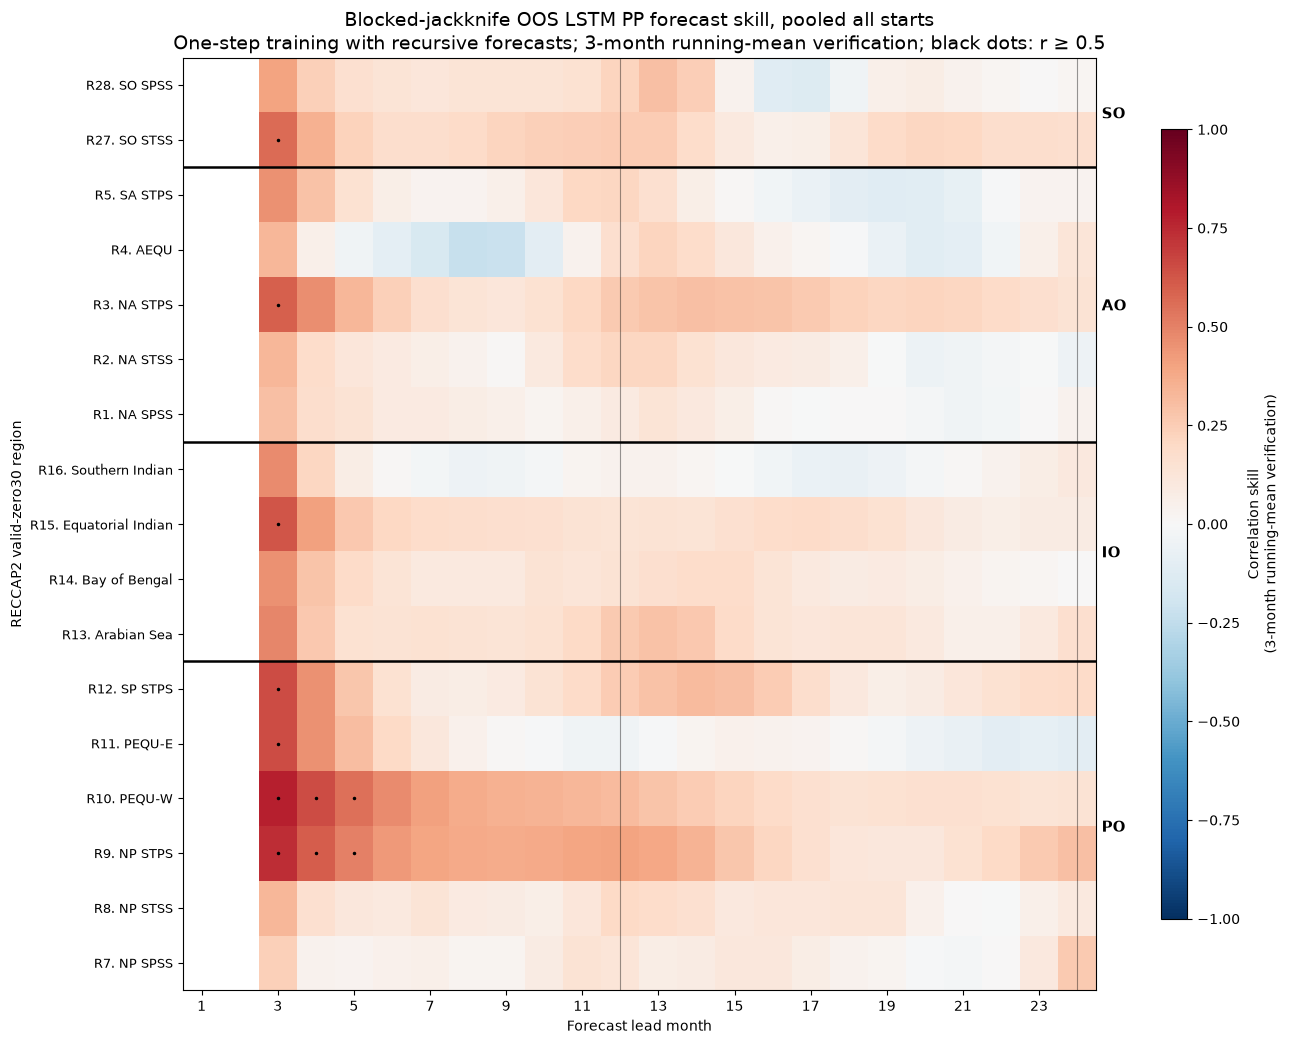

In [34]:
# ============================================================
# Heatmap: region x lead
# ============================================================

fig, ax = plt.subplots(
    figsize=(
        14.5,
        0.48 * n_region + 3.8,
    )
)

y_edges = np.arange(
    n_region + 1
)

x_edges = np.arange(
    leads[0] - 0.5,
    leads[-1] + 1.5,
    1.0,
)


im = ax.pcolormesh(
    x_edges,
    y_edges,
    r_plot.values,
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    shading="auto",
)


# ============================================================
# Mark cells with r >= threshold
# ============================================================

correlation_values = r_plot.values

for region_index, reg in enumerate(plot_regions):
    y = region_index + 0.5

    for lead_index, lead in enumerate(leads):
        value = correlation_values[
            region_index,
            lead_index,
        ]

        if (
            np.isfinite(value)
            and value >= THRESHOLD
        ):
            ax.plot(
                lead,
                y,
                "k.",
                markersize=3,
            )


# ============================================================
# Thick separators between basins
# ============================================================

for group in basin_groups[:-1]:
    boundary = group["end"] + 1

    ax.axhline(
        boundary,
        color="k",
        lw=1.8,
    )


# ============================================================
# Basin abbreviations on right
# ============================================================

if len(basin_groups) > 0:
    ax_basin = ax.twinx()

    ax_basin.set_ylim(
        0,
        n_region,
    )

    ax_basin.set_yticks(
        basin_centers
    )

    ax_basin.set_yticklabels(
        basin_labels,
        fontsize=11,
        fontweight="bold",
    )

    ax_basin.tick_params(
        axis="y",
        which="both",
        length=0,
        pad=4,
    )

    ax_basin.set_ylabel("")

    for spine in ax_basin.spines.values():
        spine.set_visible(False)


# ============================================================
# Reference lead lines
# ============================================================

if leads[-1] >= 12:
    ax.axvline(
        12,
        color="k",
        lw=0.8,
        alpha=0.4,
    )

if leads[-1] >= 24:
    ax.axvline(
        24,
        color="k",
        lw=0.8,
        alpha=0.4,
    )


# ============================================================
# Axes
# ============================================================

ax.set_xlim(
    leads[0] - 0.5,
    leads[-1] + 0.5,
)

ax.set_ylim(
    0,
    n_region,
)

ax.set_xlabel(
    "Forecast lead month"
)

ax.set_ylabel(
    "RECCAP2 valid-zero30 region"
)

ax.set_title(
    "Blocked-jackknife OOS LSTM PP forecast skill, pooled all starts\n"
    "One-step training with recursive forecasts; "
    f"{verification_label}; black dots: r ≥ {THRESHOLD}",
    fontsize=14,
)

ax.set_xticks(
    np.arange(
        leads[0],
        leads[-1] + 1,
        2,
    )
)

ax.set_yticks(
    np.arange(n_region) + 0.5
)

ax.set_yticklabels(
    [
        get_region_label(
            reg,
            short=True,
        )
        for reg in plot_regions
    ],
    fontsize=9,
)


# ============================================================
# Figure and colorbar positions
# ============================================================

fig.subplots_adjust(
    left=0.20,
    right=0.83,
    top=0.88,
    bottom=0.10,
)

cax = fig.add_axes(
    [0.875, 0.16, 0.018, 0.66]
)

cbar = fig.colorbar(
    im,
    cax=cax,
)

cbar.set_label(
    "Correlation skill\n"
    f"({verification_label})"
)

plt.show()


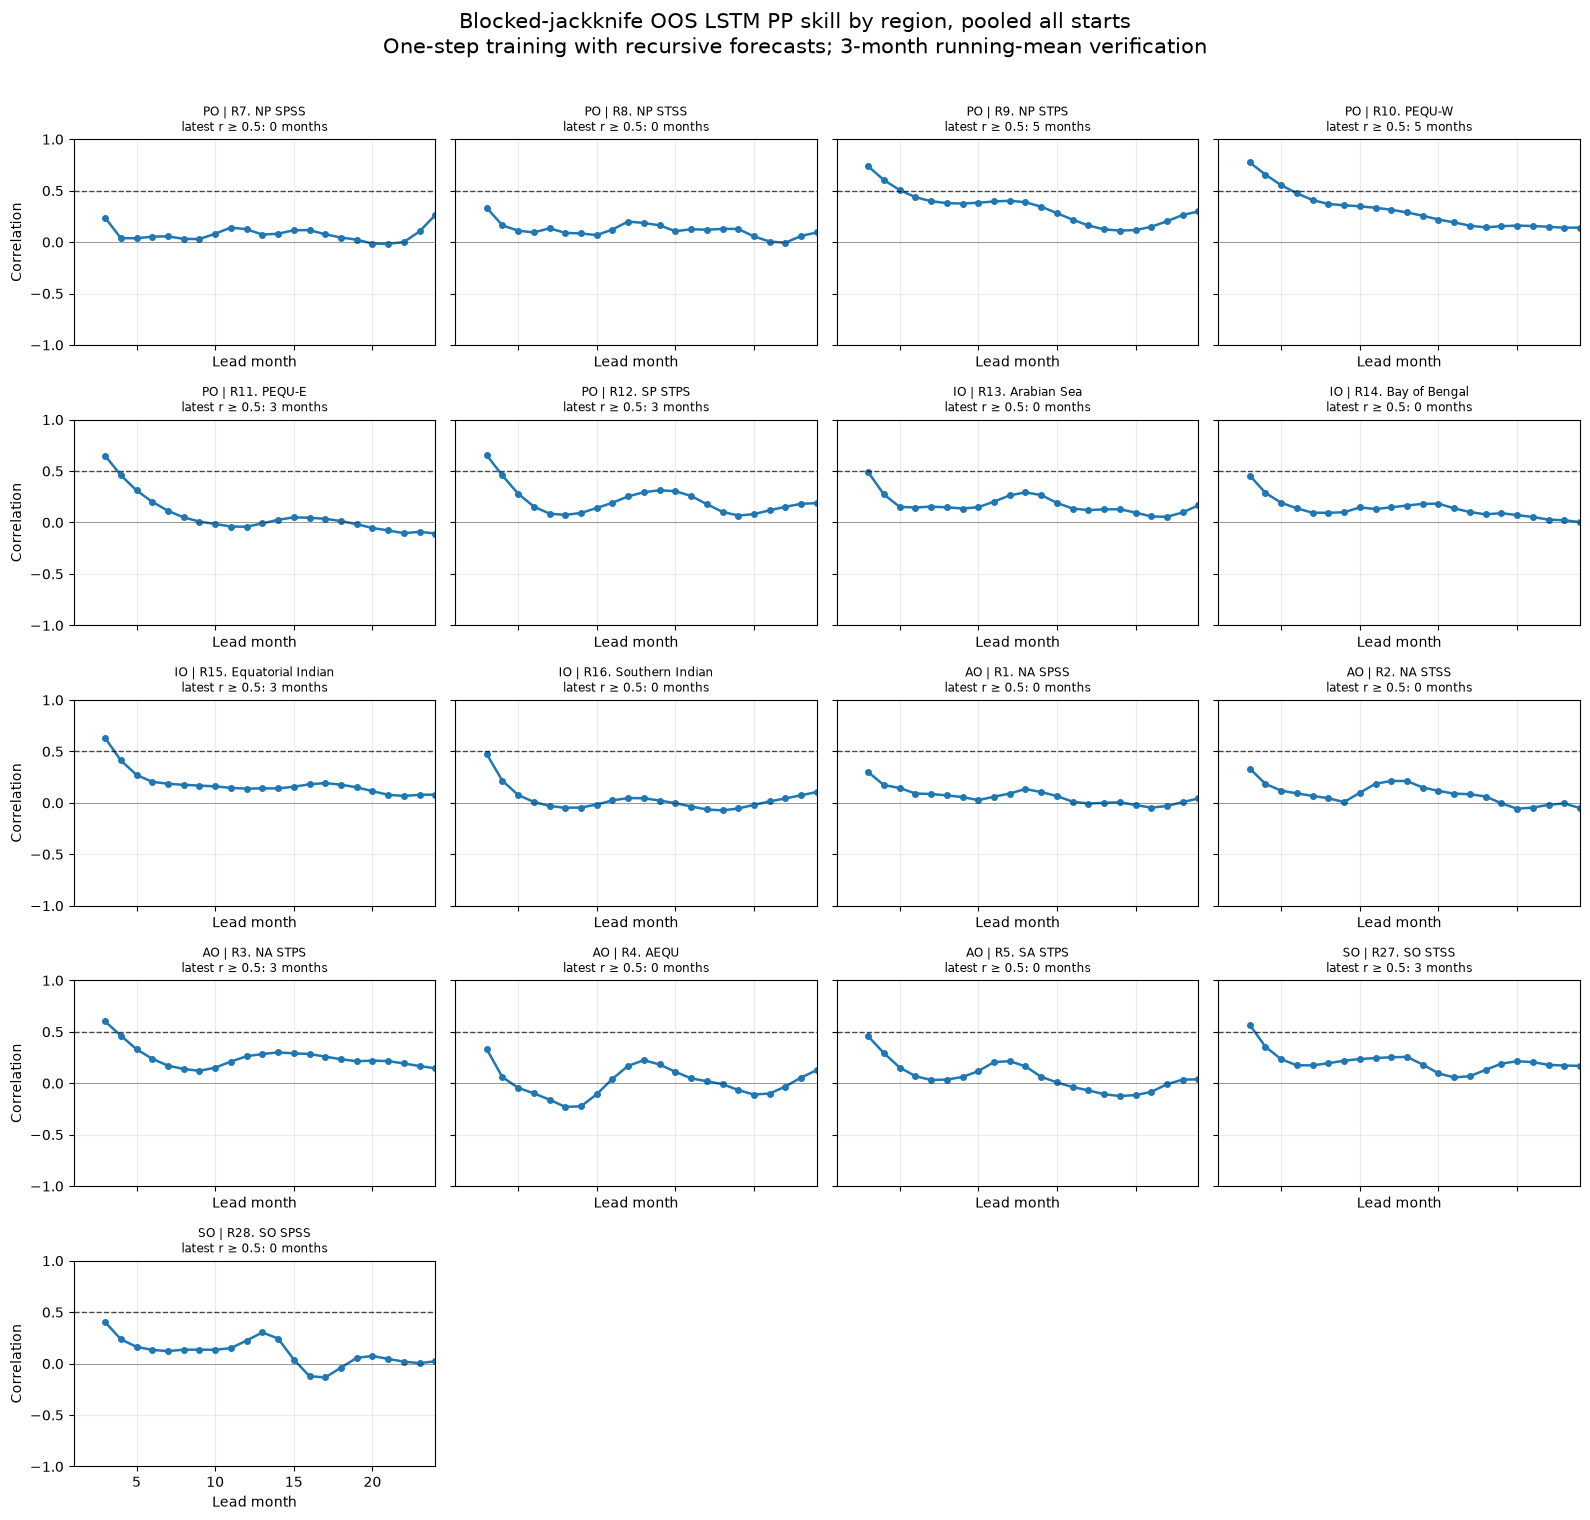

In [35]:
# ============================================================
# Regional line panels
# ============================================================

ncol = 4

nrow = int(
    np.ceil(
        n_region / ncol
    )
)

fig, axes = plt.subplots(
    nrow,
    ncol,
    figsize=(
        16,
        3.0 * nrow,
    ),
    sharex=True,
    sharey=True,
)

axes = np.asarray(
    axes
).ravel()


for ax, reg in zip(
    axes,
    plot_regions,
):
    reg = int(reg)

    region_skill = r_plot.sel(
        region=reg
    )

    basin = region_basin[reg]

    basin_short = BASIN_SHORT.get(
        basin,
        basin,
    )

    region_label = get_region_label(
        reg,
        short=True,
    )

    latest_value = int(
        latest_plot
        .sel(region=reg)
        .values
    )

    ax.plot(
        leads,
        region_skill.values,
        marker="o",
        lw=1.8,
        ms=4,
        label="LSTM",
    )

    ax.axhline(
        THRESHOLD,
        color="k",
        lw=1.0,
        ls="--",
        alpha=0.7,
    )

    ax.axhline(
        0,
        color="k",
        lw=0.6,
        alpha=0.4,
    )

    ax.set_title(
        f"{basin_short} | {region_label}\n"
        f"latest r ≥ {THRESHOLD}: {latest_value} months",
        fontsize=8.5,
    )

    ax.set_xlim(
        leads[0],
        leads[-1],
    )

    ax.set_ylim(
        -1,
        1,
    )

    ax.grid(
        alpha=0.25
    )


# Hide unused axes
for ax in axes[n_region:]:
    ax.axis("off")


# Axis labels
for index, ax in enumerate(
    axes[:n_region]
):
    ax.set_xlabel(
        "Lead month"
    )

    if index % ncol == 0:
        ax.set_ylabel(
            "Correlation"
        )


fig.suptitle(
    "Blocked-jackknife OOS LSTM PP skill by region, pooled all starts\n"
    "One-step training with recursive forecasts; "
    f"{verification_label}",
    fontsize=15,
    y=1.01,
)

plt.tight_layout()
plt.show()


Mapped regions:
[1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 27, 28]

Latest skillful lead:
Region  1:  0 months
Region  2:  0 months
Region  3:  3 months
Region  4:  0 months
Region  5:  0 months
Region  7:  0 months
Region  8:  0 months
Region  9:  5 months
Region 10:  5 months
Region 11:  3 months
Region 12:  3 months
Region 13:  0 months
Region 14:  0 months
Region 15:  3 months
Region 16:  0 months
Region 27:  3 months
Region 28:  0 months


/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/predicates.py:762: RuntimeWarning: invalid value encountered in covers
  return lib.covers(a, b, **kwargs)
/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/predicates.py:806: RuntimeWarning: invalid value encountered in disjoint
  return lib.disjoint(a, b, **kwargs)
/Users/yongyub.kim/Applications/miniconda3/envs/ml/lib/python3.11/site-packages/shapely/constructive.py:246: RuntimeWarning: invalid value encountered in buffer
  return lib.buffer(
/Users/yongyub.kim/Application

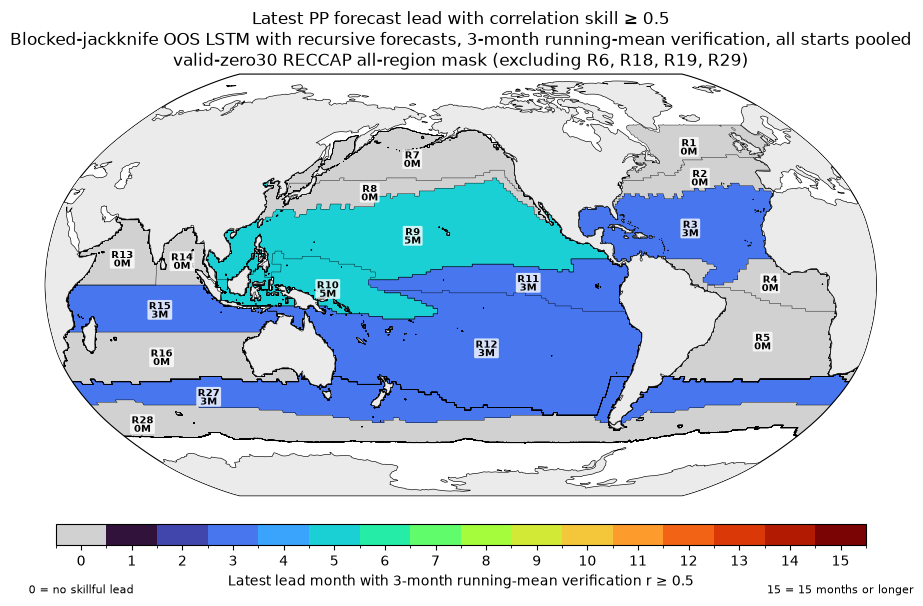

In [36]:
# ============================================================
# Check and open mask file
# ============================================================

if not VALID_MASK_FILE.exists():
    raise FileNotFoundError(
        f"Valid-mask file not found:\n"
        f"{VALID_MASK_FILE}"
    )


ds_mask = xr.open_dataset(
    VALID_MASK_FILE
)


MASK_VARIABLE = "valid_region_mask"

if MASK_VARIABLE not in ds_mask:
    raise KeyError(
        f"{MASK_VARIABLE} not found in:\n"
        f"{VALID_MASK_FILE}"
    )


# Coordinate-name handling
if "latitude" in ds_mask.coords:
    lat_name = "latitude"
elif "lat" in ds_mask.coords:
    lat_name = "lat"
else:
    raise KeyError(
        "No latitude or lat coordinate found."
    )


if "longitude" in ds_mask.coords:
    lon_name = "longitude"
elif "lon" in ds_mask.coords:
    lon_name = "lon"
else:
    raise KeyError(
        "No longitude or lon coordinate found."
    )


mask = (
    ds_mask[MASK_VARIABLE]
    .transpose(
        lat_name,
        lon_name,
    )
)

lat = (
    ds_mask[lat_name]
    .values
    .astype(float)
)

lon = (
    ds_mask[lon_name]
    .values
    .astype(float)
)

mask_values = (
    mask.values
    .astype(np.int16)
)


# ============================================================
# Exclude selected regions only for plotting
# ============================================================

mask_plot_full = mask_values.copy()

for excluded_region in EXCLUDE_REGIONS:
    mask_plot_full[
        mask_plot_full == excluded_region
    ] = 0


mask_region_set = set(
    np.unique(
        mask_plot_full[
            mask_plot_full > 0
        ]
    ).astype(int)
)


regions_to_map = [
    int(reg)
    for reg in latest_lead_da["region"].values
    if (
        int(reg) not in EXCLUDE_REGIONS
        and int(reg) in mask_region_set
    )
]


latest_map_values = (
    latest_lead_da
    .sel(region=regions_to_map)
)


print("Mapped regions:")
print(regions_to_map)

print("\nLatest skillful lead:")

for reg in regions_to_map:
    value = int(
        latest_map_values
        .sel(region=reg)
        .values
    )

    print(
        f"Region {reg:2d}: "
        f"{value:2d} months"
    )


# ============================================================
# Map region values to the PP grid
# ============================================================

lead_map = np.full(
    mask_values.shape,
    np.nan,
    dtype=np.float32,
)


for reg in regions_to_map:
    value = float(
        latest_map_values
        .sel(region=reg)
        .values
    )

    lead_map[
        mask_plot_full == reg
    ] = value


lead_map = np.where(
    mask_plot_full > 0,
    lead_map,
    np.nan,
)


# ============================================================
# Coarsen only for plotting
# ============================================================

lat_plot = lat[
    ::PLOT_STRIDE
]

lon_plot = lon[
    ::PLOT_STRIDE
]

lead_plot = lead_map[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
]

mask_plot = mask_plot_full[
    ::PLOT_STRIDE,
    ::PLOT_STRIDE,
].astype(float)


lead_cyclic, lon_cyclic = (
    add_cyclic_manual(
        lead_plot,
        lon_plot,
    )
)

mask_cyclic, _ = (
    add_cyclic_manual(
        mask_plot,
        lon_plot,
    )
)


# ============================================================
# Region boundary levels
# ============================================================

remaining_regions = np.unique(
    mask_plot_full[
        mask_plot_full > 0
    ]
)

if remaining_regions.size == 0:
    raise ValueError(
        "No regions remain after exclusions."
    )


boundary_levels = np.arange(
    0.5,
    int(
        np.nanmax(
            remaining_regions
        )
    ) + 1.5,
    1.0,
)


# ============================================================
# Discrete map color scale
# ============================================================

# Values above DISPLAY_MAX_LEAD share the final color.
# Zero means that no lead reached r >= threshold.
lead_cyclic_display = np.where(
    np.isfinite(lead_cyclic),
    np.minimum(
        lead_cyclic,
        DISPLAY_MAX_LEAD,
    ),
    np.nan,
)


bounds = np.arange(
    -0.5,
    DISPLAY_MAX_LEAD + 1.5,
    1.0,
)


try:
    base_cmap = plt.get_cmap(
        "turbo",
        DISPLAY_MAX_LEAD,
    )
except ValueError:
    base_cmap = plt.get_cmap(
        "plasma",
        DISPLAY_MAX_LEAD,
    )


colors = (
    [(0.82, 0.82, 0.82, 1.0)]
    + [
        base_cmap(i)
        for i in range(
            DISPLAY_MAX_LEAD
        )
    ]
)


map_cmap = ListedColormap(
    colors
)

map_cmap.set_bad(
    (1, 1, 1, 0)
)


map_norm = BoundaryNorm(
    bounds,
    map_cmap.N,
)


# ============================================================
# Plot map
# ============================================================

fig = plt.figure(
    figsize=(13.5, 6.2)
)

ax = plt.axes(
    projection=ccrs.Robinson(
        central_longitude=CENTRAL_LONGITUDE
    )
)


im = ax.pcolormesh(
    lon_cyclic,
    lat_plot,
    lead_cyclic_display,
    cmap=map_cmap,
    norm=map_norm,
    shading="auto",
    transform=ccrs.PlateCarree(),
)


# Region boundaries
ax.contour(
    lon_cyclic,
    lat_plot,
    mask_cyclic,
    levels=boundary_levels,
    colors="k",
    linewidths=0.30,
    transform=ccrs.PlateCarree(),
)


# Land and coastline
ax.add_feature(
    cfeature.LAND,
    facecolor="0.92",
    edgecolor="none",
    zorder=3,
)

ax.coastlines(
    linewidth=0.45,
    zorder=4,
)

ax.set_global()


# ============================================================
# Title
# ============================================================

ax.set_title(
    "Latest PP forecast lead with correlation skill ≥ 0.5\n"
    "Blocked-jackknife OOS LSTM with recursive forecasts, "
    f"{verification_label}, all starts pooled\n"
    "valid-zero30 RECCAP all-region mask "
    "(excluding R6, R18, R19, R29)",
    fontsize=12.5,
)


# ============================================================
# Region labels
# ============================================================

for reg in regions_to_map:
    region_mask = (
        mask_plot_full == reg
    )

    if not np.any(region_mask):
        continue

    lon_center, lat_center = (
        weighted_centroid(
            lon,
            lat,
            region_mask,
        )
    )

    if not (
        np.isfinite(lon_center)
        and np.isfinite(lat_center)
    ):
        continue

    value = int(
        latest_map_values
        .sel(region=reg)
        .values
    )

    label_text = (
        f"R{reg}\n"
        f"{value}M"
    )

    ax.text(
        lon_to_180(
            lon_center
        ),
        lat_center,
        label_text,
        transform=ccrs.PlateCarree(),
        ha="center",
        va="center",
        fontsize=7.2,
        fontweight="bold",
        linespacing=0.85,
        bbox=dict(
            facecolor="white",
            edgecolor="none",
            alpha=0.78,
            boxstyle="round,pad=0.14",
        ),
        zorder=5,
    )


# ============================================================
# Colorbar
# ============================================================

fig.subplots_adjust(
    left=0.03,
    right=0.97,
    top=0.84,
    bottom=0.16,
)

cax = fig.add_axes(
    [0.20, 0.08, 0.60, 0.035]
)

cbar = fig.colorbar(
    im,
    cax=cax,
    orientation="horizontal",
    ticks=np.arange(
        0,
        DISPLAY_MAX_LEAD + 1,
        1,
    ),
    boundaries=bounds,
)

cbar.set_label(
    "Latest lead month with "
    f"{verification_label} r ≥ {THRESHOLD}"
)

cbar.ax.text(
    0,
    -1.8,
    "0 = no skillful lead",
    ha="center",
    va="top",
    transform=(
        cbar.ax
        .get_xaxis_transform()
    ),
    fontsize=8,
)

cbar.ax.text(
    DISPLAY_MAX_LEAD,
    -1.8,
    (
        f"{DISPLAY_MAX_LEAD} = "
        f"{DISPLAY_MAX_LEAD} months or longer"
    ),
    ha="center",
    va="top",
    transform=(
        cbar.ax
        .get_xaxis_transform()
    ),
    fontsize=8,
)

plt.show()


# ============================================================
# Close files opened in these plotting cells
# ============================================================

ds_mask.close()

if close_region_info:
    ds_region_info.close()


In [37]:
def plot_spaghetti_region(
    region,
    every=3,
    start_date=None,
    end_date=None,
    figsize=(14, 5),
):
    region = int(region)

    forecast_pp = all_forecast_pp[region]
    init_times = all_init_times[region]

    observed = da.sel(
        region=region,
        state="PP",
    )

    observed_times = pd.to_datetime(
        observed.time.values
    )

    observed_pp = observed.values

    fig, ax = plt.subplots(figsize=figsize)

    for i in range(0, len(init_times), every):

        init_time = pd.Timestamp(init_times[i])

        # init month, lead 1, ..., lead 24
        trajectory_times = [
            init_time + pd.DateOffset(months=lead)
            for lead in range(MAX_LEAD + 1)
        ]

        initial_pp = float(
            da.sel(
                region=region,
                state="PP",
                time=init_times[i],
            ).values
        )

        # initial observed value + lead 1–24 forecasts
        trajectory_values = np.concatenate(
            [
                [initial_pp],
                forecast_pp[i, :],
            ]
        )

        ax.plot(
            trajectory_times,
            trajectory_values,
            color="tab:red",
            linewidth=1.0,
            alpha=0.45,
            zorder=3,
        )

    ax.plot(
        observed_times,
        observed_pp,
        color="k",
        linewidth=1.4,
        alpha=0.75,
        label="Observed PP",
        zorder=2,
    )

    ax.axhline(
        0,
        color="k",
        linewidth=0.6,
        alpha=0.4,
    )

    if start_date is not None:
        ax.set_xlim(left=pd.Timestamp(start_date))

    if end_date is not None:
        ax.set_xlim(right=pd.Timestamp(end_date))

    ax.set_title(
        f"Region {region}: blocked-jackknife OOS recursive LSTM forecasts"
    )

    ax.set_ylabel("Standardized PP anomaly")
    ax.set_xlabel("Target time")
    ax.grid(alpha=0.2)
    ax.legend()

    plt.tight_layout()
    plt.show()


In [38]:
def plot_all_region_spaghetti(
    regions_to_plot=None,
    every=6,
    ncol=3,
):
    if regions_to_plot is None:
        regions_to_plot = [
            int(reg)
            for reg in plot_regions
            if int(reg) in all_forecast_pp
        ]

    n_region = len(
        regions_to_plot
    )

    nrow = int(
        np.ceil(
            n_region / ncol
        )
    )

    fig, axes = plt.subplots(
        nrow,
        ncol,
        figsize=(
            17,
            3.2 * nrow,
        ),
        sharex=True,
        sharey=True,
    )

    axes = np.asarray(
        axes
    ).ravel()

    observed_times = pd.to_datetime(
        da.time.values
    )

    for ax, region in zip(
        axes,
        regions_to_plot,
    ):
        region = int(region)

        forecast_pp = (
            all_forecast_pp[region]
        )

        init_times = (
            all_init_times[region]
        )

        observed_pp = (
            da.sel(
                region=region,
                state="PP",
            )
            .values
        )

        # Forecast trajectories
        for i in range(
            0,
            len(init_times),
            every,
        ):
            init_time = pd.Timestamp(
                init_times[i]
            )

            target_times = [
                init_time
                + pd.DateOffset(
                    months=lead
                )
                for lead in range(
                    1,
                    MAX_LEAD + 1,
                )
            ]

            initial_pp = float(
                da.sel(
                    region=region,
                    state="PP",
                    time=init_times[i],
                ).values
            )

            trajectory_values = np.concatenate(
                [
                    [initial_pp],
                    forecast_pp[i, :],
                ]
            )

            ax.plot(
                [init_time] + target_times,
                trajectory_values,
                linewidth=0.55,
                alpha=0.15,
            )

        # Observed time series
        ax.plot(
            observed_times,
            observed_pp,
            color="k",
            linewidth=1.5,
            zorder=10,
        )

        ax.axhline(
            0,
            color="k",
            linewidth=0.5,
            alpha=0.4,
        )

        ax.set_title(
            f"Region {region}",
            fontsize=10,
        )

        ax.grid(
            alpha=0.15
        )

    # Hide unused axes
    for ax in axes[n_region:]:
        ax.axis("off")

    for i, ax in enumerate(
        axes[:n_region]
    ):
        if i % ncol == 0:
            ax.set_ylabel(
                "Standardized PP"
            )

    fig.suptitle(
        "Blocked-jackknife OOS recursive LSTM PP spaghetti plots\n"
        f"{MAX_LEAD}-month trajectories; "
        f"one trajectory every {every} initialization months",
        fontsize=15,
        y=1.01,
    )

    plt.tight_layout()
    plt.show()


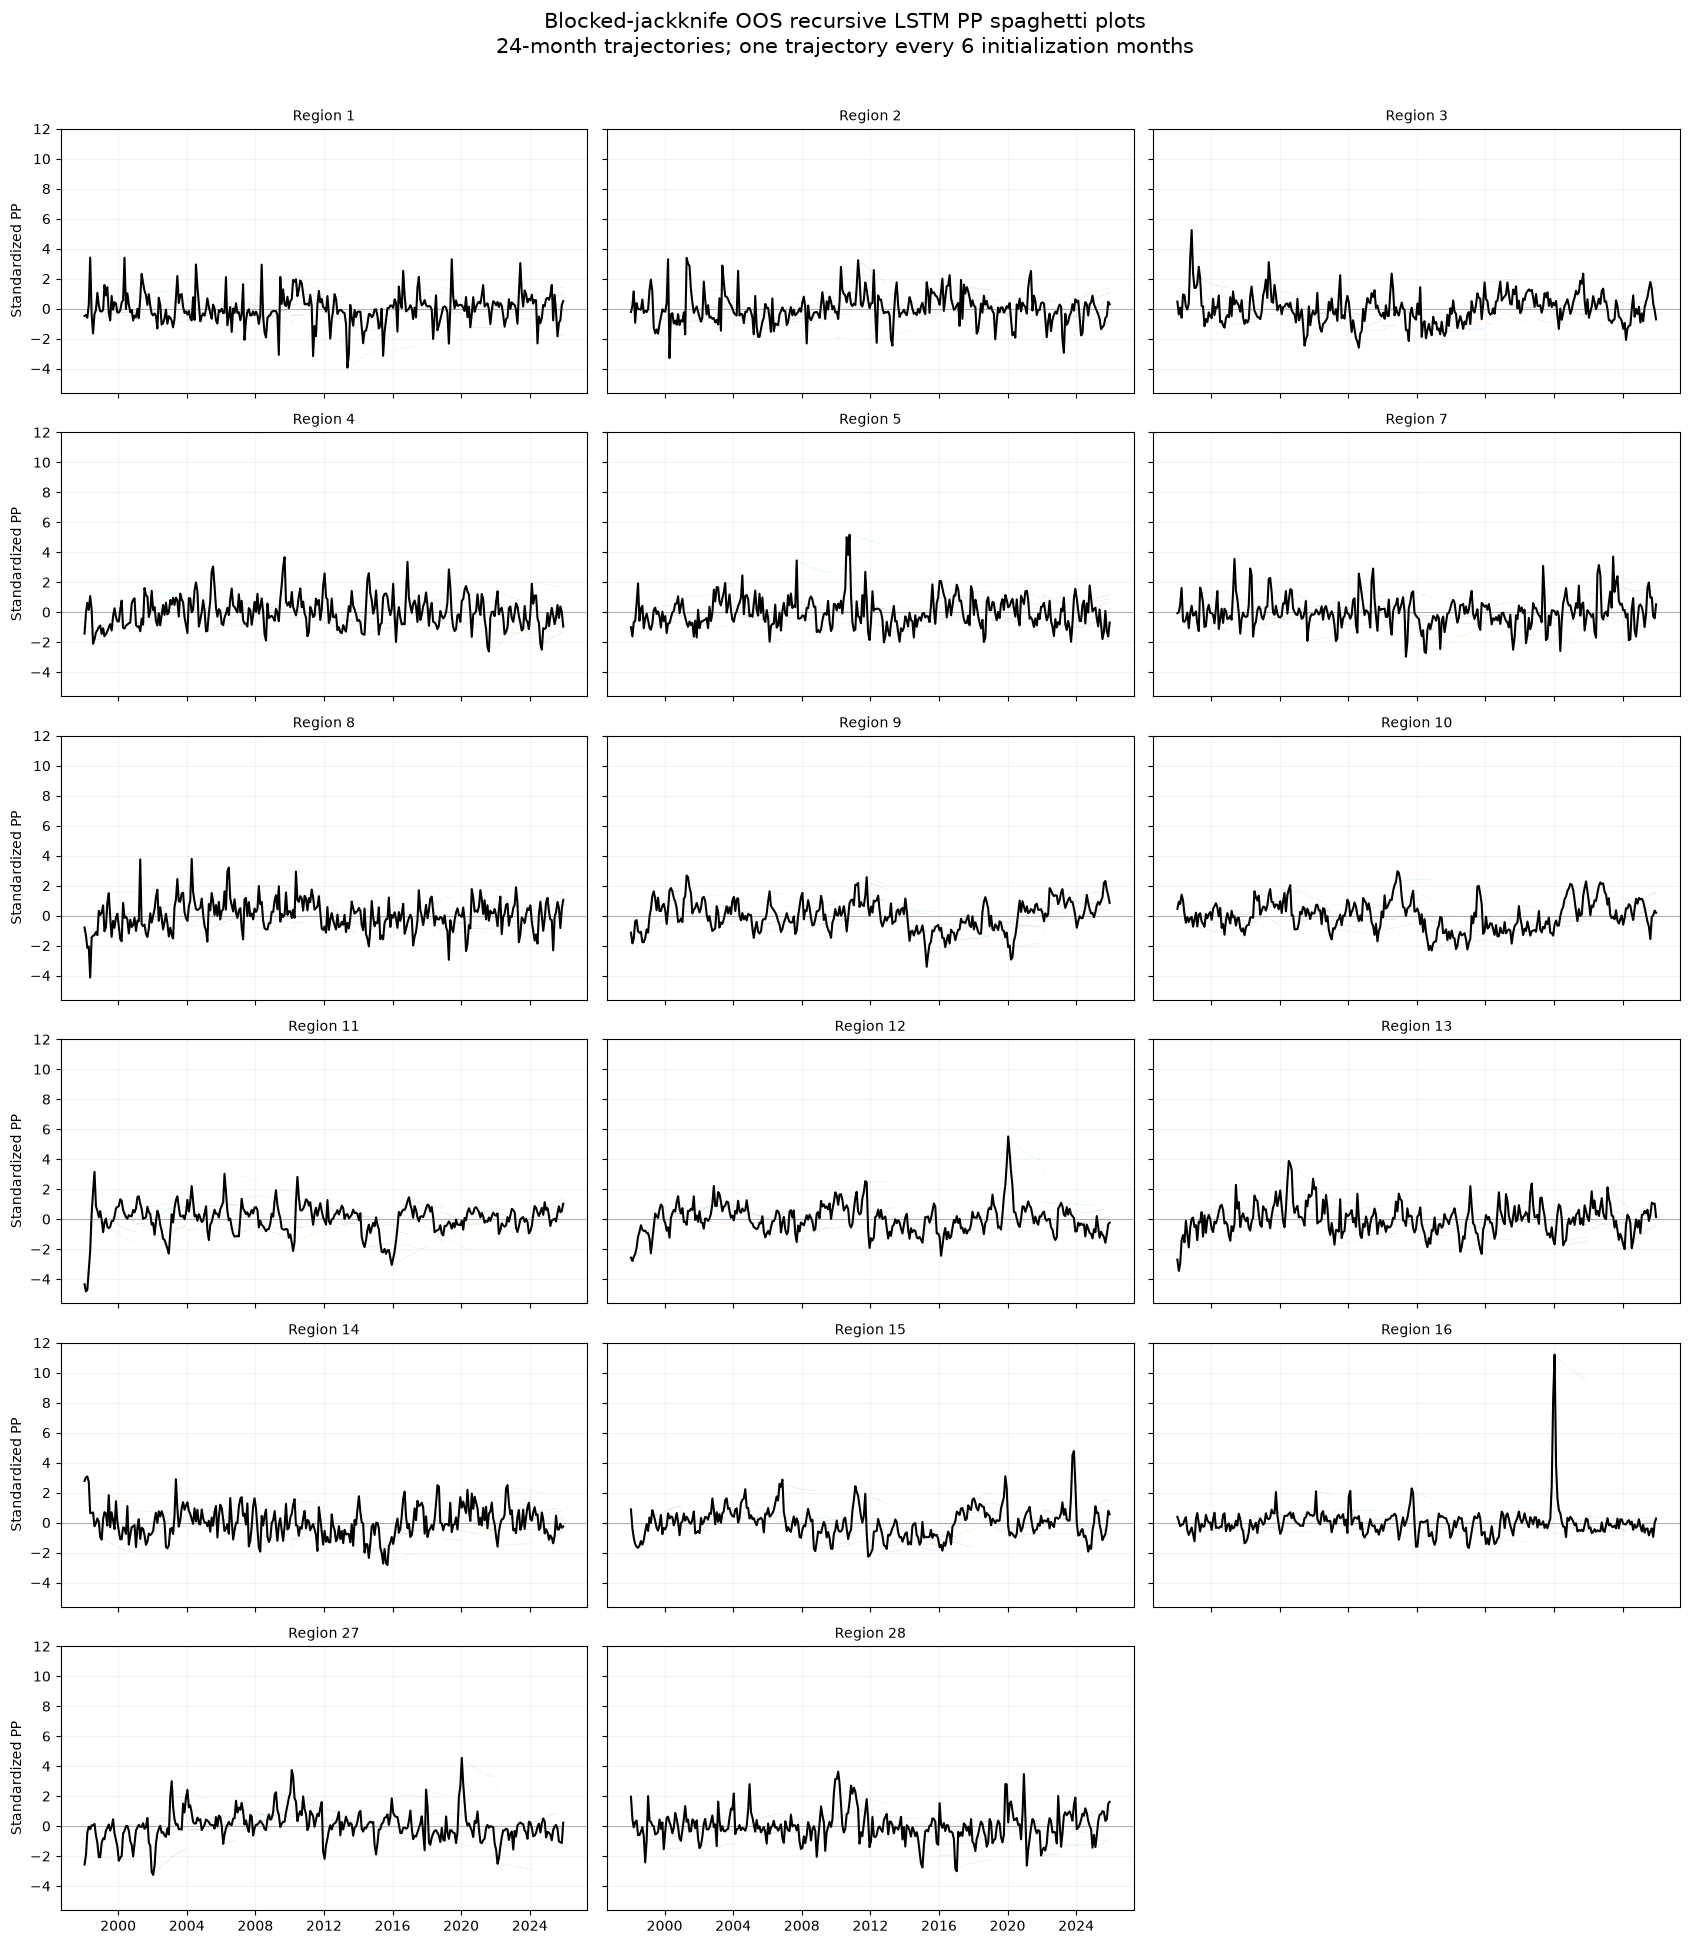

In [39]:
regions_spaghetti = [
    int(reg)
    for reg in all_regions
    if int(reg) not in [6, 18, 19, 29]
]

plot_all_region_spaghetti(
    regions_to_plot=regions_spaghetti,
    every=6,
    ncol=3,
)


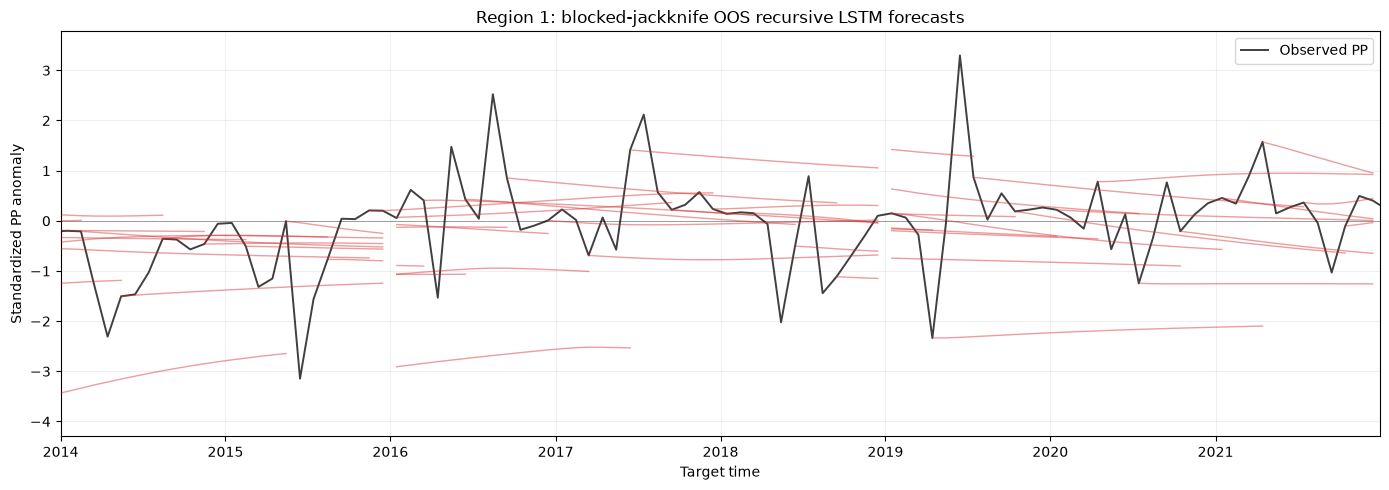

In [40]:

plot_spaghetti_region(
    region=1,
    every=3,
    start_date="2014-01-01",
    end_date="2021-12-31",
)

In [41]:
def plot_spaghetti_region_3month(
    region,
    every=3,
    start_date=None,
    end_date=None,
    window=3,
    figsize=(14, 5),
):
    region = int(region)

    # Raw monthly forecasts: [initialization, lead]
    forecast_pp = all_forecast_pp[region]
    init_times = all_init_times[region]

    # ========================================================
    # 3-month trailing mean along forecast lead
    # ========================================================

    forecast_smoothed = np.full_like(
        forecast_pp,
        np.nan,
        dtype=np.float32,
    )

    for lead_idx in range(
        window - 1,
        forecast_pp.shape[1],
    ):
        forecast_smoothed[:, lead_idx] = np.mean(
            forecast_pp[
                :,
                lead_idx - window + 1:
                lead_idx + 1,
            ],
            axis=1,
        )

    # ========================================================
    # Observed PP and corresponding 3-month trailing mean
    # ========================================================

    observed = da.sel(
        region=region,
        state="PP",
    )

    observed_smoothed = observed.rolling(
        time=window,
        min_periods=window,
    ).mean()

    observed_times = pd.to_datetime(
        observed_smoothed.time.values
    )

    observed_values = (
        observed_smoothed.values
    )

    # ========================================================
    # Plot
    # ========================================================

    fig, ax = plt.subplots(
        figsize=figsize
    )

    for i in range(
        0,
        len(init_times),
        every,
    ):
        init_time = pd.Timestamp(
            init_times[i]
        )

        # Forecast lead 1 ... MAX_LEAD
        target_times = [
            init_time
            + pd.DateOffset(months=lead)
            for lead in range(
                1,
                MAX_LEAD + 1,
            )
        ]

        ax.plot(
            target_times,
            forecast_smoothed[i, :],
            color="tab:red",
            linewidth=1.0,
            alpha=0.45,
            zorder=3,
        )

    # Observed 3-month running mean
    ax.plot(
        observed_times,
        observed_values,
        color="k",
        linewidth=1.7,
        alpha=0.85,
        label="Observed PP, 3-month mean",
        zorder=4,
    )

    ax.axhline(
        0,
        color="k",
        linewidth=0.6,
        alpha=0.4,
    )

    if start_date is not None:
        ax.set_xlim(
            left=pd.Timestamp(start_date)
        )

    if end_date is not None:
        ax.set_xlim(
            right=pd.Timestamp(end_date)
        )

    ax.set_title(
        f"Region {region}: blocked-jackknife OOS recursive LSTM forecasts\n"
        f"{window}-month trailing-mean PP"
    )

    ax.set_ylabel(
        "Standardized PP anomaly"
    )

    ax.set_xlabel(
        "Target time"
    )

    ax.grid(
        alpha=0.2
    )

    ax.legend()

    plt.tight_layout()
    plt.show()


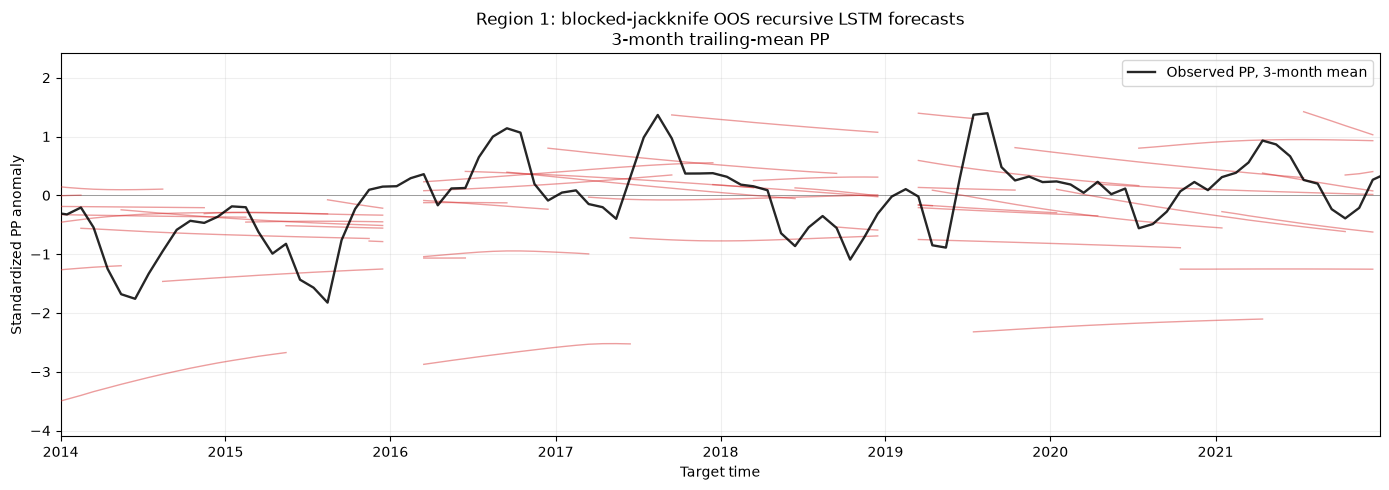

In [42]:
plot_spaghetti_region_3month(
    region=1,
    every=3,
    start_date="2014-01-01",
    end_date="2021-12-31",
)

In [43]:
def corr_valid(a, b):
    valid = np.isfinite(a) & np.isfinite(b)

    if valid.sum() < 3:
        return np.nan

    return np.corrcoef(
        a[valid],
        b[valid],
    )[0, 1]


region = 1

forecast_pp = all_forecast_pp[region]
observation_pp = all_observation_pp[region]

print("Raw monthly OOS skill")

for lead in [1, 2, 3, 6, 12, 24]:
    r = corr_valid(
        forecast_pp[:, lead - 1],
        observation_pp[:, lead - 1],
    )

    n = np.sum(
        np.isfinite(forecast_pp[:, lead - 1])
        & np.isfinite(observation_pp[:, lead - 1])
    )

    print(
        f"Lead {lead:2d}: "
        f"r={r: .3f}, n={n}"
    )

Raw monthly OOS skill
Lead  1: r= 0.352, n=324
Lead  2: r= 0.157, n=323
Lead  3: r= 0.141, n=322
Lead  6: r= 0.033, n=319
Lead 12: r= 0.091, n=313
Lead 24: r= 0.054, n=301


In [44]:
region = 1

forecast_pp = all_forecast_pp[region]
observation_pp = all_observation_pp[region]

init_times_region = pd.to_datetime(
    all_init_times[region]
)

pp_series = (
    da.sel(
        region=region,
        state="PP",
    )
    .to_series()
)

init_pp = (
    pp_series
    .loc[init_times_region]
    .values
    .astype(np.float32)
)

persistence_forecast = np.repeat(
    init_pp[:, None],
    MAX_LEAD,
    axis=1,
)

# Use exactly the same OOS target pairs
persistence_forecast[
    ~np.isfinite(observation_pp)
] = np.nan


print("Raw monthly skill comparison")

for lead in [1, 2, 3, 6, 12]:
    lstm_r = corr_valid(
        forecast_pp[:, lead - 1],
        observation_pp[:, lead - 1],
    )

    persistence_r = corr_valid(
        persistence_forecast[:, lead - 1],
        observation_pp[:, lead - 1],
    )

    print(
        f"Lead {lead:2d}: "
        f"LSTM={lstm_r: .3f}, "
        f"persistence={persistence_r: .3f}"
    )

Raw monthly skill comparison
Lead  1: LSTM= 0.352, persistence= 0.352
Lead  2: LSTM= 0.157, persistence= 0.156
Lead  3: LSTM= 0.141, persistence= 0.138
Lead  6: LSTM= 0.033, persistence= 0.020
Lead 12: LSTM= 0.091, persistence= 0.119


In [45]:
region = 1

forecast_pp = all_forecast_pp[region]
observation_pp = all_observation_pp[region]
fold_ids = all_init_folds[region]

lead = 1

print(f"Lead {lead} skill by fold")

for fold_index, block in enumerate(cv_blocks):
    select = fold_ids == fold_index

    r = corr_valid(
        forecast_pp[select, lead - 1],
        observation_pp[select, lead - 1],
    )

    n = np.sum(
        select
        & np.isfinite(forecast_pp[:, lead - 1])
        & np.isfinite(observation_pp[:, lead - 1])
    )

    print(
        f"{block['label']}: "
        f"r={r: .3f}, n={n}"
    )

Lead 1 skill by fold
1998-2000: r= 0.106, n=24
2001-2003: r= 0.581, n=36
2004-2006: r= 0.022, n=36
2007-2009: r=-0.067, n=36
2010-2012: r= 0.565, n=36
2013-2015: r= 0.376, n=36
2016-2018: r= 0.190, n=36
2019-2021: r= 0.177, n=36
2022-2025: r= 0.369, n=48


In [47]:
def diagnose_lstm_rollout(
    model,
    initial_window,
    pp_index,
    max_lead=24,
):
    window = np.asarray(
        initial_window,
        dtype=np.float32,
    ).copy()

    rows = []

    model.eval()

    with torch.no_grad():
        for lead in range(1, max_lead + 1):

            x = torch.tensor(
                window[None, :, :],
                dtype=torch.float32,
                device=device,
            )

            lstm_output, _ = model.lstm(x)
            hidden_last = lstm_output[:, -1, :]

            # Separate the state-dependent and bias components
            signal_delta = torch.nn.functional.linear(
                hidden_last,
                model.fc.weight,
                bias=None,
            )

            bias_delta = model.fc.bias[None, :]
            total_delta = signal_delta + bias_delta

            next_state = (
                x[:, -1, :]
                + total_delta
            )

            rows.append(
                {
                    "lead": lead,
                    "PP_delta_total": float(
                        total_delta[0, pp_index].cpu()
                    ),
                    "PP_delta_signal": float(
                        signal_delta[0, pp_index].cpu()
                    ),
                    "PP_delta_bias": float(
                        bias_delta[0, pp_index].cpu()
                    ),
                    "hidden_norm": float(
                        torch.linalg.vector_norm(
                            hidden_last
                        ).cpu()
                    ),
                    "predicted_PP": float(
                        next_state[0, pp_index].cpu()
                    ),
                }
            )

            next_state_np = (
                next_state.cpu().numpy()[0]
            )

            window = np.concatenate(
                [
                    window[1:, :],
                    next_state_np[None, :],
                ],
                axis=0,
            )

    return pd.DataFrame(rows)

In [48]:
init_idx = 200

initial_window = values_scaled[
    init_idx - LOOKBACK + 1:
    init_idx + 1,
    :
]

diagnosis = diagnose_lstm_rollout(
    model=model,
    initial_window=initial_window,
    pp_index=pp_index,
    max_lead=24,
)

print(diagnosis)

NameError: name 'model' is not defined